In [1]:
#general libraries
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#adequacy testing
!pip install factor_analyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo

#factor analysis
from factor_analyzer import FactorAnalyzer
!pip install pingouin
import pingouin as pg

#manova
from statsmodels.multivariate.manova import MANOVA


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42568 sha256=ff9ef42337775390a872745a9589a951ea29e357e76083effc453598c498d2a3
  Stored in directory: /root/.cache/pip/wheels/24/59/82/6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor_analyzer
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 7.0 MB/s eta 0:00:00


In [2]:
#import whole dataset
from google.colab import drive
drive.mount('/content/drive')

dfa = pd.read_excel('/content/drive/My Drive/DSC/Data/music.xlsx')

Mounted at /content/drive


In [3]:
dfa.head()

,Who is your favorite musical artist?,What genre is their music?,This artist thinks like me.,This artist is similar to me.,This artist is like me.,This artist shares my values.,This artist has a lot in common with me.,This artist behaves like me.,This artist has thoughts and ideas that are similar to mine.,I think they could be a friend of mine.,...,"If this artist releases merchandise, I want to buy it.",I would be willing to spend more on merchandise for this artist.,I want to stream music by this artist.,I want to purchase a copy of this artist’s music.,"How many minutes have you listened to this artist in the past week?\nIf you use an app like airbuds or last.fm give the number the app shares, otherwise give your best estimate.",How much have you spent on merchandise for this artist?,How much have you spent on tickets to see this artist?,What is your age?,Gender,Household Income
0,Flatland Cavalry,Country,4,1,1,3,1,3,4,4,...,2,1,5,3,60,0,0,21,Male,$125K+
1,Lil Peep,Rap,2,2,4,2,2,2,3,4,...,4,4,5,4,120,50,0,20,Male,$75K - $99K
2,Tyler the Creator,Hip-Hop,3,1,1,3,1,1,1,3,...,4,4,4,4,2251,70,550,21,Male,Prefer not to answer
3,Tyler the Creator,"Hip-hop, Pop, Neo-Soul, Jazz, R&B",4,2,3,5,1,3,4,3,...,5,5,5,5,180,0,0,20,Male,$100K - $124K
4,Porter Robinson,Pop,1,2,2,2,2,2,2,4,...,2,2,5,2,300,0,100,19,Male,Prefer not to answer


In [4]:
dfa = dfa.drop(dfa.columns[[0, 1]], axis=1)
#columns 1 and 2 are dropped because column 1 was to ensure participants had only one artist in mind as they answered questions
#column 2's answers are too diverse to generate useful insights

In [5]:
dfa.drop(dfa.columns[[17,18]], axis=1, inplace=True)
dfa.head()
#very little was in these rows so we can't use them

,This artist thinks like me.,This artist is similar to me.,This artist is like me.,This artist shares my values.,This artist has a lot in common with me.,This artist behaves like me.,This artist has thoughts and ideas that are similar to mine.,I think they could be a friend of mine.,I would like to have a friendly chat with them.,This artist treats people like I do.,"If this artist goes on tour, I want to buy tickets.",I would be willing to spend more on tickets to see this artist.,"If this artist releases merchandise, I want to buy it.",I would be willing to spend more on merchandise for this artist.,I want to stream music by this artist.,I want to purchase a copy of this artist’s music.,"How many minutes have you listened to this artist in the past week?\nIf you use an app like airbuds or last.fm give the number the app shares, otherwise give your best estimate.",What is your age?,Gender,Household Income
0,4,1,1,3,1,3,4,4,4,3,4,4,2,1,5,3,60,21,Male,$125K+
1,2,2,4,2,2,2,3,4,4,3,4,4,4,4,5,4,120,20,Male,$75K - $99K
2,3,1,1,3,1,1,1,3,2,3,5,5,4,4,4,4,2251,21,Male,Prefer not to answer
3,4,2,3,5,1,3,4,3,4,5,5,5,5,5,5,5,180,20,Male,$100K - $124K
4,1,2,2,2,2,2,2,4,4,3,5,5,2,2,5,2,300,19,Male,Prefer not to answer


<Axes: >

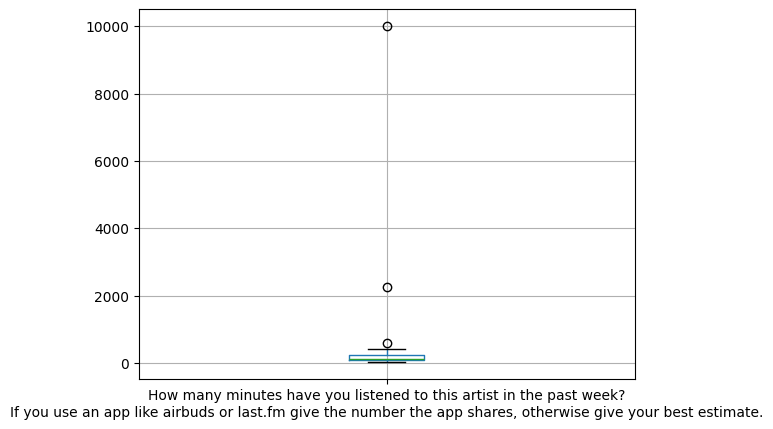

In [6]:
dfa.boxplot(column=['How many minutes have you listened to this artist in the past week?\nIf you use an app like airbuds or last.fm give the number the app shares, otherwise give your best estimate.'])

<Axes: >

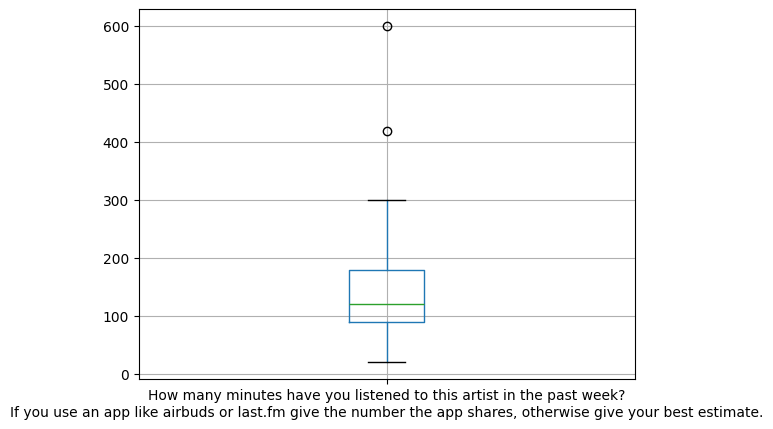

In [7]:
dfa = dfa.drop(dfa[dfa['How many minutes have you listened to this artist in the past week?\nIf you use an app like airbuds or last.fm give the number the app shares, otherwise give your best estimate.'] > 1000].index)
dfa.boxplot(column=['How many minutes have you listened to this artist in the past week?\nIf you use an app like airbuds or last.fm give the number the app shares, otherwise give your best estimate.'])

In [8]:
dfa.shape

(21, 20)

In [9]:
sim_df = dfa[dfa.columns[0:10]]
will_df = dfa[dfa.columns[10:16]]
#making a smaller datasets based on question categories to make work easier

#Similarity

In [10]:
sim_df.head()

,This artist thinks like me.,This artist is similar to me.,This artist is like me.,This artist shares my values.,This artist has a lot in common with me.,This artist behaves like me.,This artist has thoughts and ideas that are similar to mine.,I think they could be a friend of mine.,I would like to have a friendly chat with them.,This artist treats people like I do.
0,4,1,1,3,1,3,4,4,4,3
1,2,2,4,2,2,2,3,4,4,3
3,4,2,3,5,1,3,4,3,4,5
4,1,2,2,2,2,2,2,4,4,3
5,2,3,2,2,2,4,1,2,4,2


###Testing Adequacy for Factor Analysis

In [11]:
#checking adequacy as a factor
chi_square_value,p_value=calculate_bartlett_sphericity(sim_df)
chi_square_value, p_value
#Bartlett's test is significant so that means it isn't an identity matrix so we're good to go

(130.8332439639858, 2.622187656287184e-10)

In [12]:
kmo_all,kmo_model=calculate_kmo(sim_df)
kmo_model
#Overall KMO > 0.6 meaning this is adequate to continue

0.6798499038716038

###Number of Factors

In [13]:
fa = FactorAnalyzer(n_factors=1)
fa.fit(sim_df)
# Check Eigenvalues
ev, v = fa.get_eigenvalues()
loadings = fa.loadings_

/usr/local/lib/python3.10/dist-packages/factor_analyzer/factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(


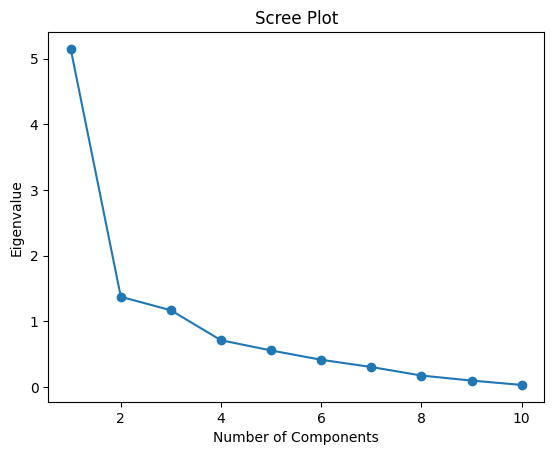

In [14]:
plt.plot(range(1, len(ev) + 1), ev, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.show()
#last large drop is from 1 to 2 - so that means only 1 factor

In [15]:
alp=pg.cronbach_alpha(data=sim_df)
print(alp)
#using cronbach's alpha to double-check fitness of grouping these together
#confidence rating is high so we'll turn these into 1 variable

(0.8926989569938564, array([0.808, 0.95 ]))


###Calculating the Similarity Score

In [16]:
sim = sim_df.mean(axis=1)
new_df = dfa[dfa.columns[16:24]]
new_df['percieved_similarity'] = sim
new_df = new_df.rename(columns={'How many minutes have you listened to this artist in the past week?\nIf you use an app like airbuds or last.fm give the number the app shares, otherwise give your best estimate.': 'minutes', 'What is your age?': 'Age','Household Income':'Income'})
new_df.head()
#taking an average of the percieved similarity scores because it takes pretty advanced statistics to get proper weighted scores
#and python doesn't have great tools for calculating it built-in

<ipython-input-16-cf147d85a0cb>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['percieved_similarity'] = sim


,minutes,Age,Gender,Income,percieved_similarity
0,60,21,Male,$125K+,2.8
1,120,20,Male,$75K - $99K,2.8
3,180,20,Male,$100K - $124K,3.4
4,300,19,Male,Prefer not to answer,2.4
5,22,22,Male,Prefer not to answer,2.4


#Willingness to Support

###Adequacy

In [17]:
#checking adequacy as a factor
chi_square_value,p_value=calculate_bartlett_sphericity(will_df)
chi_square_value, p_value
#Bartlett's test is significant so that means it isn't an identity matrix so we're good to go

(69.62819380811803, 5.202560211584989e-09)

In [18]:
kmo_all,kmo_model=calculate_kmo(will_df)
kmo_model
#Overall KMO > 0.6 meaning this is adequate to continue

0.6720367666210818

###Number of Factors

In [19]:
faw = FactorAnalyzer(n_factors=1)
faw.fit(will_df)
# Check Eigenvalues
evw, vw = faw.get_eigenvalues()
loads = faw.loadings_

/usr/local/lib/python3.10/dist-packages/factor_analyzer/factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(


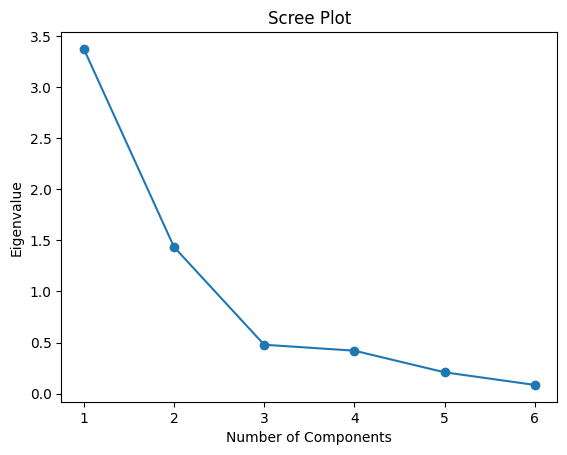

In [20]:
plt.plot(range(1, len(evw) + 1), evw, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.show()
#last large drop is from 1 to 2 - so that means only 1 factor

In [21]:
loads

array([[-0.61522537],
       [-0.81049683],
       [-0.85124145],
       [-0.77274168],
       [-0.39337199],
       [-0.64448137]])

In [22]:
#Note second-to-last loading is very low, this row won't be calculated into the factor
will_df = will_df.drop(will_df.columns[[4]], axis=1)

In [23]:
alph=pg.cronbach_alpha(data=will_df)
print(alph)
#using cronbach's alpha to double-check fitness of grouping these together
#confidence rating is high so we'll turn these into 1 variable

(0.8573786201022147, array([0.731, 0.935]))


###Calculating Willingness Score

In [24]:
will = will_df.mean(axis=1)
new_df['willingness'] = will

In [25]:
new_df.head()

,minutes,Age,Gender,Income,percieved_similarity,willingness
0,60,21,Male,$125K+,2.8,2.8
1,120,20,Male,$75K - $99K,2.8,4.0
3,180,20,Male,$100K - $124K,3.4,5.0
4,300,19,Male,Prefer not to answer,2.4,3.2
5,22,22,Male,Prefer not to answer,2.4,4.0


##Splitting the Population

In [26]:
split = np.average(new_df['percieved_similarity'])
new_df['pop'] = np.where(new_df['percieved_similarity'] >= split, 'high', 'low')

#MANOVA

##Assumptions

####Mulitcollinearity

In [27]:
corr = new_df.corr(numeric_only=True)
corr
#The variables we were looking at do not have incredibly high correlation with each other so multicollinearity is not a problem

,minutes,Age,percieved_similarity,willingness
minutes,1.000000,-0.107602,0.341145,0.157095
Age,-0.107602,1.000000,0.117678,-0.278205
percieved_similarity,0.341145,0.117678,1.000000,0.649010
willingness,0.157095,-0.278205,0.649010,1.000000


###Variance

In [28]:
round(new_df.groupby('pop').var(numeric_only=True),2)
#minutes has a pretty large difference so we'll do a logarithmic transformation to make it more suitable for MANOVA
new_df['min_log'] = np.log(new_df['minutes'])
round(new_df.groupby('pop').var(numeric_only=True),2)

,minutes,Age,percieved_similarity,willingness,min_log
pop,,,,,
high,29005.45,1.20,0.14,0.64,0.79
low,8161.17,1.56,0.30,0.66,0.66


##Test

In [29]:
manova = MANOVA.from_formula('min_log + willingness ~ pop', data=new_df)
result = manova.mv_test()
print(result)

                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept         Value  Num DF  Den DF F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda  0.0240 2.0000 18.0000 365.9329 0.0000
         Pillai's trace  0.9760 2.0000 18.0000 365.9329 0.0000
 Hotelling-Lawley trace 40.6592 2.0000 18.0000 365.9329 0.0000
    Roy's greatest root 40.6592 2.0000 18.0000 365.9329 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
            pop           Value  Num DF  Den DF F Value Pr > F
--------------------------------------------------------------
            Wilks' lambda 0.6367 2.0000 18.0000  5.1358 0.0172
           Pillai's trace 0.3633 2.0000 18.0000  5.1358 0.0172
   Hotellin

In [35]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Perform ANOVA for willingness to support
model_willingness = ols('will ~ C(pop)', data=new_df).fit()
anova_results_willingness = sm.stats.anova_lm(model_willingness, typ=2)

# Perform ANOVA for listening behavior
model_listening = ols('min_log ~ C(pop)', data=new_df).fit()
anova_results_listening = sm.stats.anova_lm(model_listening, typ=2)

print("ANOVA Results for Willingness to Support:\n", anova_results_willingness)
print('\n')
print("ANOVA Results for Listening Behavior:\n", anova_results_listening)

ANOVA Results for Willingness to Support:
              sum_sq    df         F    PR(>F)
C(pop)     5.469160   1.0  8.366425  0.009332
Residual  12.420364  19.0       NaN       NaN


ANOVA Results for Listening Behavior:
              sum_sq    df        F    PR(>F)
C(pop)     0.774230   1.0  1.06306  0.315465
Residual  13.837761  19.0      NaN       NaN
